# House Price Prediction Pipeline
## DSS5104 — CA 1

## 0. Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, SplineTransformer
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone
from xgboost import XGBRegressor
from typing import Optional, Dict, List, Tuple

RESULTS_DIR = "results"
DATA_PATH = "house_dataset.csv"
RANDOM_STATE = 42
TEST_SIZE = 0.2

os.makedirs(RESULTS_DIR, exist_ok = True)

## 1. Data Loading and Cleaning

In [2]:
def load_and_clean(path = DATA_PATH):
    """Load CSV and perform basic cleaning."""
    df = pd.read_csv(path)

    # Deduplicate
    n_before_dedup = len(df)
    df = df.drop_duplicates().reset_index(drop = True)
    n_dedup_removed = n_before_dedup - len(df)
    if n_dedup_removed > 0:
        print(f"  Removed {n_dedup_removed} exact duplicate rows ({n_before_dedup} -> {len(df)})")

    # Parse date
    df["date"] = pd.to_datetime(df["date"])
    df["sale_month"] = df["date"].dt.month

    # Extract zip code from statezip (e.g. "WA 98133" -> "98133")
    df["zipcode"] = df["statezip"].str.extract(r"(\d+)").astype(str)

    # Remove rows with price <= 0
    n_before = len(df)
    df = df[df["price"] > 0].copy()
    n_removed = n_before - len(df)
    if n_removed > 0:
        print(f"  Removed {n_removed} rows with price <= 0")

    # Remove extreme outliers
    price_per_sqft = df["price"] / df["sqft_living"].replace(0, 1)
    n_before = len(df)
    outlier_mask = (price_per_sqft > 5000) | (price_per_sqft < 20)
    outlier_mask |= (df["bedrooms"] == 0) & (df["bathrooms"] == 0)
    df = df[~outlier_mask].copy()
    n_outliers = n_before - len(df)
    if n_outliers > 0:
        print(f"  Removed {n_outliers} extreme outlier rows")

    # Drop columns we won't use directly
    df = df.drop(columns = ["date", "street", "statezip", "country"])

    return df


def split_data(df, test_size = TEST_SIZE, random_state = RANDOM_STATE):
    """Split into train/test (stratified by city)."""
    city_counts = df["city"].value_counts()
    rare_cities = city_counts[city_counts < 10].index
    strat_col = df["city"].where(~df["city"].isin(rare_cities), "Other")

    X = df.drop(columns = ["price"])
    y = df["price"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size = test_size, random_state = random_state, stratify = strat_col
    )

    print(f"  Train size: {len(X_train)}, Test size: {len(X_test)}")
    return X_train, X_test, y_train, y_test

In [3]:
print("[1/7] Loading and cleaning data ...")
df = load_and_clean()
print(f"  Data shape after cleaning: {df.shape}")
print("[1/7] Task completed")

print("\n[2/7] Splitting data ...")
X_train, X_test, y_train, y_test = split_data(df)
print("[2/7] Task completed")

[1/7] Loading and cleaning data ...
  Removed 4598 exact duplicate rows (9200 -> 4602)
  Removed 49 rows with price <= 0
  Removed 5 extreme outlier rows
  Data shape after cleaning: (4548, 16)
[1/7] Task completed

[2/7] Splitting data ...
  Train size: 3638, Test size: 910
[2/7] Task completed


## 2. Feature Engineering

In [4]:
class FeatureEngineer:
    """Stateful feature transformer — fit on train, transform train and test."""

    def __init__(self):
        self.city_target_enc = None
        self.zip_target_enc = None
        self.zip_std_enc = None
        self.city_count_enc = None
        self.zip_count_enc = None
        self.global_mean_log_price = 0.0
        self.global_std_log_price = 1.0
        self.scaler = None
        self.feature_names = []

        # KNN components (dual-scale)
        self._knn_model_local = None
        self._knn_model_broad = None
        self._knn_log_prices = None
        self._knn_scaler = None
        self._knn_cols = []

        # Spline transformers
        self._splines = {}
        self._spline_config = {}

        # KMeans clustering
        self._kmeans = None
        self._kmeans_scaler = None
        self._kmeans_cols = []

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------
    def fit_transform(self, X, y):
        X = X.copy()

        self.global_mean_log_price = np.log1p(y).mean()
        self.global_std_log_price = np.log1p(y).std()

        # Target encodings (median-based for robustness)
        self._fit_target_encoding(X, y, col = "city", store = "city_target_enc")
        self._fit_target_encoding(X, y, col = "zipcode", store = "zip_target_enc")

        # Zip-code price variability encoding
        self._fit_std_encoding(X, y, col = "zipcode", store = "zip_std_enc")

        # Count encodings
        self.city_count_enc = X["city"].value_counts().to_dict()
        self.zip_count_enc = X["zipcode"].value_counts().to_dict()

        # Build core features (needed for KNN, splines, clustering)
        feats = self._build_core_features(X)

        # KNN neighbourhood features (dual-scale, fit on training data)
        self._fit_knn(feats, y)
        knn_feats = self._transform_knn(feats, is_training = True)

        # KMeans clustering features
        self._fit_kmeans(feats)
        cluster_feats = self._transform_kmeans(feats)

        # Spline basis expansions on key variables
        spline_vars = {
            "log_sqft_living": {"n_knots": 6, "degree": 3},
            "log_sqft_lot": {"n_knots": 5, "degree": 3},
            "house_age": {"n_knots": 5, "degree": 3},
            "zip_enc": {"n_knots": 6, "degree": 3},
            "city_enc": {"n_knots": 5, "degree": 3},
            "effective_age": {"n_knots": 5, "degree": 3},
        }
        self._fit_splines(feats, spline_vars)
        spline_feats = self._transform_splines(feats)

        feats = pd.concat([feats, knn_feats, cluster_feats, spline_feats], axis = 1)

        # Scale
        self.scaler = StandardScaler()
        self.feature_names = list(feats.columns)
        arr = self.scaler.fit_transform(feats)
        return pd.DataFrame(arr, columns = self.feature_names, index = feats.index)

    def transform(self, X):
        X = X.copy()

        feats = self._build_core_features(X)
        knn_feats = self._transform_knn(feats)
        cluster_feats = self._transform_kmeans(feats)
        spline_feats = self._transform_splines(feats)
        feats = pd.concat([feats, knn_feats, cluster_feats, spline_feats], axis = 1)

        for col in self.feature_names:
            if col not in feats.columns:
                feats[col] = 0.0
        feats = feats[self.feature_names]

        arr = self.scaler.transform(feats)

        return pd.DataFrame(arr, columns = self.feature_names, index = feats.index)

    # ------------------------------------------------------------------
    # Core feature construction
    # ------------------------------------------------------------------
    def _build_core_features(self, X):
        feats = pd.DataFrame(index = X.index)

        # ---- Core numeric ----
        feats["bedrooms"] = X["bedrooms"]
        feats["bathrooms"] = X["bathrooms"]
        feats["floors"] = X["floors"]
        feats["waterfront"] = X["waterfront"].astype(float)
        feats["view"] = X["view"].astype(float)
        feats["condition"] = X["condition"].astype(float)

        # ---- Log-transformed sizes ----
        feats["log_sqft_living"] = np.log1p(X["sqft_living"])
        feats["log_sqft_lot"] = np.log1p(X["sqft_lot"])
        feats["log_sqft_above"] = np.log1p(X["sqft_above"])
        feats["log_sqft_basement"] = np.log1p(X["sqft_basement"])

        # ---- Age features ----
        feats["house_age"] = (2014 - X["yr_built"]).clip(lower = 0).astype(float)
        feats["was_renovated"] = (X["yr_renovated"] > 0).astype(float)

        feats["effective_age"] = np.where(
            X["yr_renovated"] > 0, 
            (2014 - X["yr_renovated"]).clip(lower = 0), 
            feats["house_age"]).astype(float)

        feats["log_effective_age"] = np.log1p(feats["effective_age"])
        feats["age_decade"] = (feats["house_age"] // 10).astype(float)

        # ---- Size ratios ----
        total_rooms = (X["bedrooms"] + X["bathrooms"]).replace(0, 1)
        feats["total_rooms"] = total_rooms.astype(float)

        feats["sqft_per_room"] = X["sqft_living"] / total_rooms
        feats["log_sqft_per_room"] = np.log1p(feats["sqft_per_room"])

        feats["has_basement"] = (X["sqft_basement"] > 0).astype(float)
        feats["basement_frac"] = X["sqft_basement"] / X["sqft_living"].replace(0, 1)

        feats["bed_bath_ratio"] = X["bedrooms"] / X["bathrooms"].replace(0, 1)

        feats["living_to_lot"] = X["sqft_living"] / X["sqft_lot"].replace(0, 1)
        feats["log_living_to_lot"] = np.log1p(feats["living_to_lot"])

        # ---- Quality indicators ----
        feats["high_view"] = (X["view"] >= 3).astype(float)
        feats["high_condition"] = (X["condition"] >= 4).astype(float)
        feats["low_condition"] = (X["condition"] <= 2).astype(float)

        feats["premium"] = (
            (X["waterfront"] == 1) | (X["view"] >= 3) | (X["condition"] == 5)
        ).astype(float)

        # ---- Unusual property indicators ----
        feats["many_bedrooms"] = (X["bedrooms"] >= 6).astype(float)
        feats["few_bedrooms"] = (X["bedrooms"] <= 1).astype(float)

        feats["large_house"] = (X["sqft_living"] >= 4000).astype(float)
        feats["small_house"] = (X["sqft_living"] <= 800).astype(float)

        feats["very_old"] = (feats["house_age"] >= 80).astype(float)
        feats["new_build"] = (feats["house_age"] <= 5).astype(float)
        feats["modern_build"] = (X["yr_built"] >= 2000).astype(float)

        feats["large_lot"] = (X["sqft_lot"] >= 40000).astype(float)

        # ---- Polynomial terms ----
        feats["log_living_sq"] = feats["log_sqft_living"] ** 2
        feats["log_sqft_lot_sq"] = feats["log_sqft_lot"] ** 2
        feats["log_effective_age_sq"] = feats["log_effective_age"] ** 2

        feats["bath_sq"] = feats["bathrooms"] ** 2
        feats["condition_sq"] = feats["condition"] ** 2
        feats["view_sq"] = feats["view"] ** 2

        # ---- Interactions ----
        feats["log_living_x_cond"] = feats["log_sqft_living"] * feats["condition"]
        feats["log_living_x_view"] = feats["log_sqft_living"] * feats["view"]
        feats["log_living_x_floors"] = feats["log_sqft_living"] * feats["floors"]
        feats["log_living_x_rooms"] = feats["log_sqft_living"] * feats["total_rooms"]
        feats["log_living_x_wf"] = feats["log_sqft_living"] * feats["waterfront"] 
        feats["log_living_x_bath"] = feats["log_sqft_living"] * feats["bathrooms"]
        feats["log_living_x_age"] = feats["log_sqft_living"] * feats["house_age"]
        feats["log_living_x_bed_bath"] = feats["log_sqft_living"] * feats["bed_bath_ratio"]
        feats["log_living_x_basement"] = feats["log_sqft_living"] * feats["has_basement"]

        feats["age_x_cond"] = feats["house_age"] * feats["condition"]
        feats["age_x_reno"] = feats["house_age"] * feats["was_renovated"]
        
        feats["wf_x_view"] = feats["waterfront"] * feats["view"]
        feats["cond_x_view"] = feats["condition"] * feats["view"]

        feats["basement_x_age"] = feats["has_basement"].astype(float) * feats["house_age"]
        feats["floors_x_cond"] = feats["floors"] * feats["condition"]

        # ---- Seasonal ----
        month = X["sale_month"].astype(float)
        feats["sale_sin_month"] = np.sin(2 * np.pi * month / 12)
        feats["sale_cos_month"] = np.cos(2 * np.pi * month / 12)

        # ---- Location encodings ----
        feats["city_enc"] = (
            X["city"].map(self.city_target_enc).fillna(self.global_mean_log_price)
        )

        feats["zip_enc"] = (
            X["zipcode"].map(self.zip_target_enc).fillna(self.global_mean_log_price)
        )

        feats["zip_city_diff"] = feats["zip_enc"] - feats["city_enc"]

        feats["city_count"] = X["city"].map(self.city_count_enc).fillna(1).astype(float)
        feats["zip_count"] = X["zipcode"].map(self.zip_count_enc).fillna(1).astype(float)
        feats["log_city_count"] = np.log1p(feats["city_count"])
        feats["log_zip_count"] = np.log1p(feats["zip_count"])

        feats["zip_std"] = (
            X["zipcode"].map(self.zip_std_enc).fillna(self.global_std_log_price)
        )

        # Location x property interactions
        feats["zip_x_sqft"] = feats["zip_enc"] * feats["log_sqft_living"]
        feats["zip_x_cond"] = feats["zip_enc"] * feats["condition"]

        feats["city_x_sqft"] = feats["city_enc"] * feats["log_sqft_living"]

        feats["wf_x_zip"] = feats["waterfront"] * feats["zip_enc"]
        feats["view_x_zip"] = feats["view"] * feats["zip_enc"]

        feats["zip_enc_sq"] = feats["zip_enc"] ** 2
        feats["city_enc_sq"] = feats["city_enc"] ** 2

        return feats

    # ------------------------------------------------------------------
    # Dual-scale KNN neighbourhood features
    # ------------------------------------------------------------------
    def _fit_knn(self, feats, y):
        knn_feature_cols = [
            "log_sqft_living", "log_sqft_lot", "bathrooms", "bedrooms",
            "floors", "condition", "view", "house_age", "zip_enc", "city_enc",
        ]
        self._knn_cols = [c for c in knn_feature_cols if c in feats.columns]
        X_knn = feats[self._knn_cols].values

        self._knn_scaler = StandardScaler()
        X_knn_scaled = self._knn_scaler.fit_transform(X_knn)
        self._knn_log_prices = np.log1p(y.values)

        # Hyperlocal (k = 10)
        self._knn_model_local = NearestNeighbors(n_neighbors = 11, metric = "euclidean")
        self._knn_model_local.fit(X_knn_scaled)

        # Broader neighbourhood (k = 25)
        self._knn_model_broad = NearestNeighbors(n_neighbors = 26, metric = "euclidean")
        self._knn_model_broad.fit(X_knn_scaled)

    def _transform_knn(self, feats, is_training = False):
        X_knn = feats[self._knn_cols].values
        X_knn_scaled = self._knn_scaler.transform(X_knn)

        knn_feats = pd.DataFrame(index = feats.index)

        # --- Hyperlocal (k = 10) ---
        distances, indices = self._knn_model_local.kneighbors(X_knn_scaled)
        if is_training:
            # Skip index 0 (self) when querying training data
            neighbor_prices = self._knn_log_prices[indices[:, 1:]]
            neighbor_dists = distances[:, 1:]
        else:
            # For new data, all 11 results are genuine neighbours; take closest 10
            neighbor_prices = self._knn_log_prices[indices[:, :10]]
            neighbor_dists = distances[:, :10]

        knn_feats["knn_mean"] = neighbor_prices.mean(axis = 1)
        knn_feats["knn_median"] = np.median(neighbor_prices, axis = 1)
        knn_feats["knn_std"] = neighbor_prices.std(axis = 1)
        knn_feats["knn_max"] = neighbor_prices.max(axis = 1)
        knn_feats["knn_min"] = neighbor_prices.min(axis = 1)
        knn_feats["knn_p25"] = np.percentile(neighbor_prices, 25, axis = 1)
        knn_feats["knn_p75"] = np.percentile(neighbor_prices, 75, axis = 1)
        knn_feats["knn_iqr"] = knn_feats["knn_p75"] - knn_feats["knn_p25"]

        # Distance-weighted mean
        weights = 1.0 / (neighbor_dists + 1e-6)
        weights = weights / weights.sum(axis = 1, keepdims = True)
        knn_feats["knn_weighted_mean"] = (neighbor_prices * weights).sum(axis = 1)
        knn_feats["knn_mean_dist"] = neighbor_dists.mean(axis = 1)

        # --- Broader neighbourhood (k = 25) ---
        distances_b, indices_b = self._knn_model_broad.kneighbors(X_knn_scaled)
        if is_training:
            neighbor_prices_b = self._knn_log_prices[indices_b[:, 1:]]
            neighbor_dists_b = distances_b[:, 1:]
        else:
            neighbor_prices_b = self._knn_log_prices[indices_b[:, :25]]
            neighbor_dists_b = distances_b[:, :25]

        knn_feats["knn_broad_mean"] = neighbor_prices_b.mean(axis = 1)
        knn_feats["knn_broad_std"] = neighbor_prices_b.std(axis = 1)

        weights_b = 1.0 / (neighbor_dists_b + 1e-6)
        weights_b = weights_b / weights_b.sum(axis = 1, keepdims = True)
        knn_feats["knn_broad_weighted"] = (neighbor_prices_b * weights_b).sum(axis = 1)

        # Local vs broad difference
        knn_feats["knn_local_vs_broad"] = knn_feats["knn_mean"] - knn_feats["knn_broad_mean"]

        return knn_feats

    # ------------------------------------------------------------------
    # KMeans clustering features
    # ------------------------------------------------------------------
    def _fit_kmeans(self, feats, n_clusters = 8):
        self._kmeans_cols = [
            "log_sqft_living", "bathrooms", "bedrooms", "condition",
            "floors", "log_effective_age",
        ]
        self._kmeans_cols = [c for c in self._kmeans_cols if c in feats.columns]
        X_km = feats[self._kmeans_cols].values.astype(np.float64)

        self._kmeans_scaler = StandardScaler()
        X_km_scaled = self._kmeans_scaler.fit_transform(X_km)

        self._kmeans = KMeans(n_clusters = n_clusters, 
                              random_state = RANDOM_STATE, n_init = 10)
        self._kmeans.fit(X_km_scaled)

    def _transform_kmeans(self, feats):
        X_km = feats[self._kmeans_cols].values.astype(np.float64)
        X_km_scaled = self._kmeans_scaler.transform(X_km)

        labels = self._kmeans.predict(X_km_scaled)
        distances = self._kmeans.transform(X_km_scaled)

        cluster_feats = pd.DataFrame(index = feats.index)

        # One-hot encode cluster labels
        for i in range(self._kmeans.n_clusters):
            cluster_feats[f"cluster_{i}"] = (labels == i).astype(float)

        # Distance to assigned cluster center
        cluster_feats["cluster_dist"] = distances[np.arange(len(labels)), labels]

        return cluster_feats

    # ------------------------------------------------------------------
    # Spline features on multiple variables
    # ------------------------------------------------------------------
    def _fit_splines(self, feats, spline_config):
        self._spline_config = spline_config
        self._splines = {}

        for col, params in spline_config.items():
            if col in feats.columns:
                x = feats[[col]].values
                st = SplineTransformer(
                    n_knots = params["n_knots"],
                    degree = params["degree"],
                    include_bias = False,
                )
                st.fit(x)
                self._splines[col] = st

    def _transform_splines(self, feats):
        all_splines = []

        for col, st in self._splines.items():
            x = feats[[col]].values
            arr = st.transform(x)
            cols = [f"spl_{col}_{i}" for i in range(arr.shape[1])]
            all_splines.append(pd.DataFrame(arr, columns = cols, index = feats.index))

        if all_splines:
            return pd.concat(all_splines, axis = 1)
        return pd.DataFrame(index = feats.index)

    # ------------------------------------------------------------------
    # Target encoding 
    # ------------------------------------------------------------------
    def _fit_target_encoding(self, X, y, col, store):
        log_y = np.log1p(y)
        tmp = pd.DataFrame({col: X[col].values, "target": log_y.values})
        agg = tmp.groupby(col)["target"].agg(["median", "count"])
        m = 50
        smooth = (agg["count"] * agg["median"] + m * self.global_mean_log_price) / (agg["count"] + m)
        setattr(self, store, smooth.to_dict())

    def _fit_std_encoding(self, X, y, col, store):
        """Encode price variability per category."""
        log_y = np.log1p(y)
        tmp = pd.DataFrame({col: X[col].values, "target": log_y.values})
        agg = tmp.groupby(col)["target"].agg(["std", "count"])
        agg["std"] = agg["std"].fillna(self.global_std_log_price)
        m = 50
        smooth = (agg["count"] * agg["std"] + m * self.global_std_log_price) / (agg["count"] + m)
        setattr(self, store, smooth.to_dict())

In [5]:
print("[3/7] Engineering features ...")
fe = FeatureEngineer()
X_train_fe = fe.fit_transform(X_train, y_train)
X_test_fe = fe.transform(X_test)
print(f"  Feature count: {X_train_fe.shape[1]}")

# Sanity checks
assert not X_train_fe.isnull().any().any(), "NaN found in training features!"
assert not X_test_fe.isnull().any().any(), "NaN found in test features!"

print("[3/7] Task completed")

[3/7] Engineering features ...
  Feature count: 134
[3/7] Task completed


## 3. Linear Model Training 

In [6]:
def _cv_mape(model_class, model_params, X_raw, y_price, n_splits = 5, random_state = RANDOM_STATE, sample_weight_fn = None):
    """Proper CV with feature engineering re-fit inside each fold."""
    kf = KFold(n_splits = n_splits, shuffle = True, random_state = random_state)
    mapes = []

    for train_idx, val_idx in kf.split(X_raw):
        X_tr_raw = X_raw.iloc[train_idx]
        X_val_raw = X_raw.iloc[val_idx]
        y_tr = y_price.iloc[train_idx]
        y_val = y_price.iloc[val_idx]

        fe_fold = FeatureEngineer()
        X_tr_fe = fe_fold.fit_transform(X_tr_raw, y_tr)
        X_val_fe = fe_fold.transform(X_val_raw)

        y_tr_log = np.log1p(y_tr)
        model = model_class(**model_params)
        sw = sample_weight_fn(y_tr) if sample_weight_fn else None
        
        if sw is not None:
            model.fit(X_tr_fe, y_tr_log, sample_weight = sw)
        else:
            model.fit(X_tr_fe, y_tr_log)

        pred_price = np.expm1(model.predict(X_val_fe))
        pred_price = np.clip(pred_price, 0, None)

        mask = y_val > 0
        fold_mape = np.mean(
            np.abs((y_val[mask] - pred_price[mask.values]) / y_val[mask])
        )
        mapes.append(fold_mape)

    return np.mean(mapes), np.std(mapes)


def _mape_weight(y_price):
    """Weight samples inversely by log-price to balance MAPE contributions."""
    return 1.0 / np.log1p(y_price)


def predict_price(model, X):
    """Predict actual prices (inverse log transform)."""
    y_pred_log = model.predict(X)
    return np.expm1(y_pred_log)


def get_coefficients(model, feature_names):
    """Extract and sort model coefficients."""
    coef = model.coef_ if hasattr(model, 'coef_') else np.zeros(len(feature_names))
    coefs = pd.DataFrame({"feature": feature_names, "coefficient": coef})
    coefs["abs_coefficient"] = coefs["coefficient"].abs()
    coefs = coefs.sort_values("abs_coefficient", ascending = False).reset_index(drop = True)
    return coefs

In [7]:
print("[4/7] Training linear model ...")

candidates = []

# Ridge with MAPE-balancing weights
for a in [0.05, 0.1, 0.5, 1.0, 5.0, 10.0]:
    candidates.append((f"Ridge(a = {a}, wt)", Ridge, {"alpha": a, "random_state": RANDOM_STATE}, _mape_weight))

# Lasso
for a in [1e-5, 5e-5, 0.0001, 0.0005, 0.001, 0.005, 0.01]:
    candidates.append((f"Lasso(a = {a})", Lasso, {"alpha": a, "max_iter": 20000, "random_state": RANDOM_STATE}, None))

print(f" CV (FE refit per fold) ...")
cv_results = {}
best_mape_val = np.inf
best_name = None
best_params = None
best_class = None
best_weight_fn = None

for i, (name, cls, params, weight_fn) in enumerate(candidates):
    mean_mape_val, std_mape_val = _cv_mape(
        cls, params, X_train, y_train, 5, sample_weight_fn = weight_fn,
    )

    cv_results[name] = (mean_mape_val, std_mape_val)

    if mean_mape_val < best_mape_val:
        best_mape_val = mean_mape_val
        best_name = name
        best_params = params
        best_class = cls
        best_weight_fn = weight_fn

    print(f"    {i + 1} / {len(candidates)}. {name}: MAPE = {mean_mape_val:.4f} +/- {std_mape_val:.4f}")

# Refit best model on full training data
y_train_log = np.log1p(y_train)
best_model = best_class(**best_params)
sw = best_weight_fn(y_train) if best_weight_fn else None

if sw is not None:
    best_model.fit(X_train_fe, y_train_log, sample_weight = sw)
else:
    best_model.fit(X_train_fe, y_train_log)

print(f"\n  Best model: {best_name} (CV MAPE = {best_mape_val:.4f})")

coef = best_model.coef_ if hasattr(best_model, 'coef_') else np.zeros(X_train_fe.shape[1])
n_nonzero = np.sum(np.abs(coef) > 1e-10)

print(f"  Non-zero coefficients: {n_nonzero}/{len(coef)}")

print("[4/7] Task completed")

[4/7] Training linear model ...
 CV (FE refit per fold) ...
    1 / 13. Ridge(a = 0.05, wt): MAPE = 0.1780 +/- 0.0196
    2 / 13. Ridge(a = 0.1, wt): MAPE = 0.1778 +/- 0.0192
    3 / 13. Ridge(a = 0.5, wt): MAPE = 0.1774 +/- 0.0179
    4 / 13. Ridge(a = 1.0, wt): MAPE = 0.1773 +/- 0.0173
    5 / 13. Ridge(a = 5.0, wt): MAPE = 0.1769 +/- 0.0162
    6 / 13. Ridge(a = 10.0, wt): MAPE = 0.1768 +/- 0.0160
    7 / 13. Lasso(a = 1e-05): MAPE = 0.1792 +/- 0.0207
    8 / 13. Lasso(a = 5e-05): MAPE = 0.1784 +/- 0.0199
    9 / 13. Lasso(a = 0.0001): MAPE = 0.1780 +/- 0.0193
    10 / 13. Lasso(a = 0.0005): MAPE = 0.1774 +/- 0.0169
    11 / 13. Lasso(a = 0.001): MAPE = 0.1771 +/- 0.0163
    12 / 13. Lasso(a = 0.005): MAPE = 0.1782 +/- 0.0162
    13 / 13. Lasso(a = 0.01): MAPE = 0.1801 +/- 0.0150

  Best model: Ridge(a = 10.0, wt) (CV MAPE = 0.1768)
  Non-zero coefficients: 134/134
[4/7] Task completed


## 4. Evaluation Utilities

In [8]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error. Excludes observations where y_true == 0."""
    y_true = np.asarray(y_true, dtype = float)
    y_pred = np.asarray(y_pred, dtype = float)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])))


def print_metrics(y_true, y_pred, label = "Model"):
    """Print key regression metrics including log-space R2."""
    m = mape(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    y_true_pos = np.maximum(y_true, 1)
    y_pred_pos = np.maximum(y_pred, 1)
    r2_log = r2_score(np.log1p(y_true_pos), np.log1p(y_pred_pos))

    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  MAPE     : {m:.4f}  ({m * 100:.2f}%)")
    print(f"  MAE      : ${mae:,.0f}")
    print(f"  RMSE     : ${rmse:,.0f}")
    print(f"  R2       : {r2:.4f}")
    print(f"  R2 (log) : {r2_log:.4f}")
    print(f"{'='*50}\n")
    return {"mape": m, "mae": mae, "rmse": rmse, "r2": r2, "r2_log": r2_log}


def segment_mape(y_true, y_pred, save_name = None):
    """Compute and display MAPE by price segment."""
    y_true = np.asarray(y_true, dtype = float)
    y_pred = np.asarray(y_pred, dtype = float)

    bins = [0, 200_000, 400_000, 600_000, 800_000, 1_000_000, 2_000_000, float("inf")]
    labels = ["<$200K", "$200K-$400K", "$400K-$600K", "$600K-$800K",
              "$800K-$1M", "$1M-$2M", ">$2M"]

    rows = []
    print("\n  MAPE by Price Segment:")
    print(f"  {'Segment':<15} {'MAPE':>8} {'Count':>6}")
    print(f"  {'-'*15} {'-'*8} {'-'*6}")

    for i in range(len(bins) - 1):
        mask = (y_true >= bins[i]) & (y_true < bins[i + 1])
        if mask.sum() > 0:
            seg_mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))
            print(f"  {labels[i]:<15} {seg_mape:>7.1%} {mask.sum():>6}")
            rows.append({"segment": labels[i], "mape": seg_mape, "count": int(mask.sum())})

    if save_name:
        pd.DataFrame(rows).to_csv(os.path.join(RESULTS_DIR, save_name), index = False)

    return rows


def plot_predictions(y_true, y_pred, title = "Predicted vs Actual", save_name = None):
    """Scatter plot of predicted vs actual prices."""
    fig, axes = plt.subplots(1, 2, figsize = (14, 6))

    ax = axes[0]
    ax.scatter(y_true, y_pred, alpha = 0.3, s = 10, color = "#4A90D9")
    lim_max = max(np.max(y_true), np.max(y_pred)) * 1.05
    ax.plot([0, lim_max], [0, lim_max], "r--", linewidth = 1, label = "Perfect prediction")

    ax.set_xlabel("Actual Price ($)")
    ax.set_ylabel("Predicted Price ($)")
    ax.set_title(title)

    ax.legend()
    ax.set_xlim(0, lim_max)
    ax.set_ylim(0, lim_max)

    ax = axes[1]
    residuals = y_pred - y_true
    ax.scatter(y_true, residuals, alpha = 0.3, s = 10, color = "#E74C3C")
    ax.axhline(0, color = "black", linewidth = 0.8)

    ax.set_xlabel("Actual Price ($)")
    ax.set_ylabel("Residual ($)")
    ax.set_title("Residuals")

    plt.tight_layout()

    if save_name:
        path = os.path.join(RESULTS_DIR, save_name)
        plt.savefig(path, dpi = 150, bbox_inches = "tight")
        print(f"  Plot saved to {path}")

    plt.show()


def plot_feature_importance(feature_names, coefficients, top_n = 20, save_name = None):
    """Plot top feature importances (absolute coefficient values)."""
    importance = pd.Series(np.abs(coefficients), index = feature_names).sort_values(ascending = False)
    top = importance.head(top_n)

    fig, ax = plt.subplots(figsize = (10, 8))

    top.sort_values().plot.barh(ax = ax, color = "#2ECC71")

    ax.set_xlabel("Absolute Coefficient (standardised)")
    ax.set_title(f"Top {top_n} Feature Importances (Linear Model)")

    plt.tight_layout()

    if save_name:
        path = os.path.join(RESULTS_DIR, save_name)
        plt.savefig(path, dpi = 150, bbox_inches = "tight")
        print(f"  Plot saved to {path}")

    plt.show()

    return importance

## 5. Linear Model Evaluation

In [9]:
y_pred_linear = predict_price(best_model, X_test_fe)
y_pred_linear = np.clip(y_pred_linear, 0, None)

linear_metrics = print_metrics(y_test.values, y_pred_linear, f"Linear Model ({best_name})")
segment_mape(y_test.values, y_pred_linear, save_name = "linear_segment_mape.csv");


  Linear Model (Ridge(a = 10.0, wt))
  MAPE     : 0.1681  (16.81%)
  MAE      : $94,901
  RMSE     : $180,765
  R2       : 0.8026
  R2 (log) : 0.8222


  MAPE by Price Segment:
  Segment             MAPE  Count
  --------------- -------- ------
  <$200K            46.3%     34
  $200K-$400K       14.8%    317
  $400K-$600K       16.1%    283
  $600K-$800K       14.4%    147
  $800K-$1M         14.8%     57
  $1M-$2M           19.7%     63
  >$2M              30.5%      9


In [10]:
# Feature importance
coefs = get_coefficients(best_model, fe.feature_names)
print("  Top 15 features by absolute coefficient:")
coefs.head(15)

  Top 15 features by absolute coefficient:


,feature,coefficient,abs_coefficient
0,log_sqft_above,0.061417,0.061417
1,city_count,0.048743,0.048743
2,zip_enc_sq,0.039458,0.039458
3,knn_median,0.039337,0.039337
4,zip_enc,0.039102,0.039102
5,spl_log_sqft_living_5,0.036437,0.036437
6,zip_city_diff,0.035812,0.035812
7,knn_weighted_mean,0.033006,0.033006
8,basement_frac,-0.031657,0.031657
9,knn_broad_weighted,0.028744,0.028744


  Plot saved to results/linear_model_predictions.png


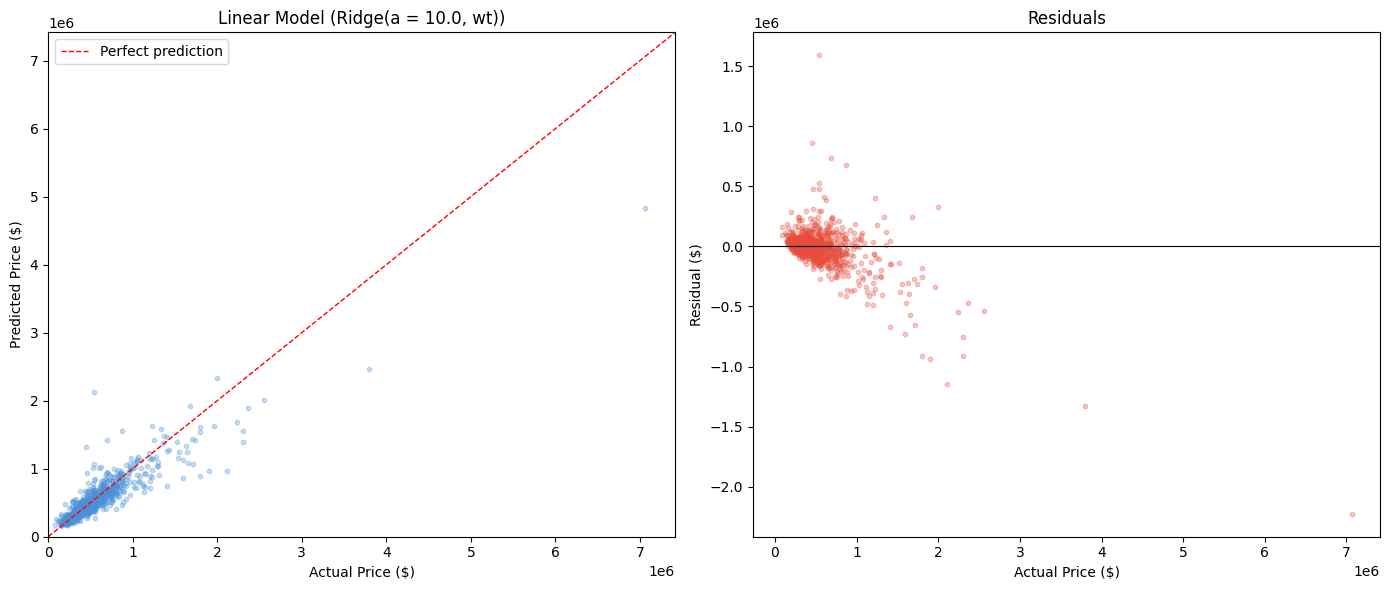

  Plot saved to results/linear_model_feature_importance.png


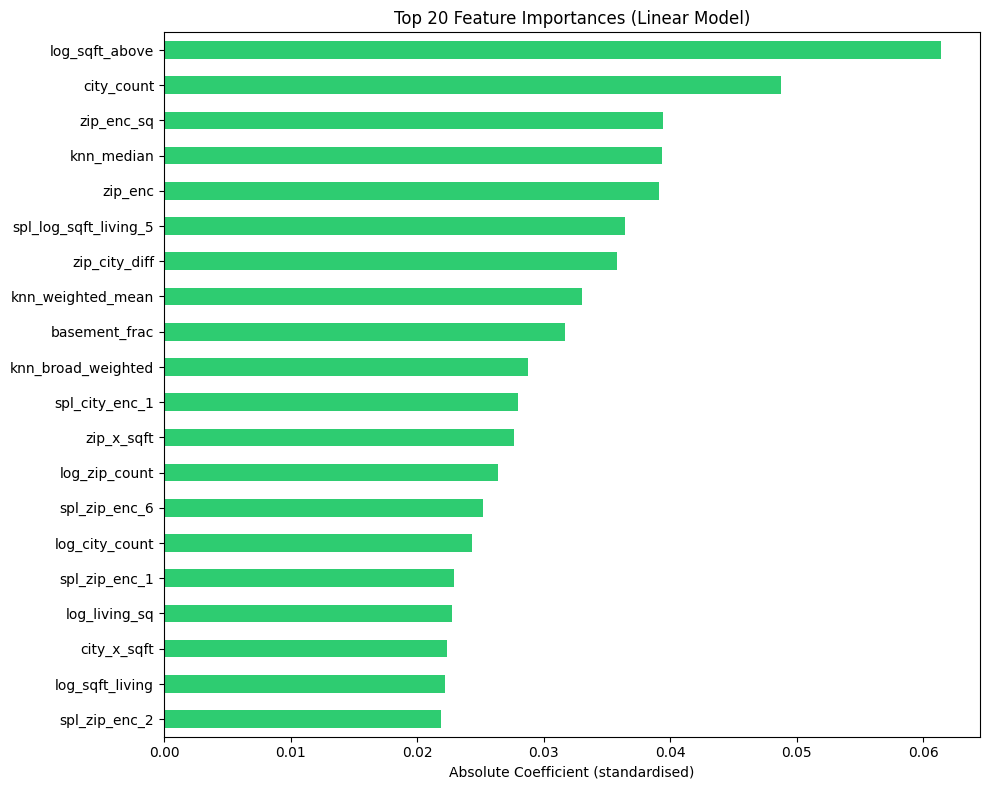

log_sqft_above    0.061417
city_count        0.048743
zip_enc_sq        0.039458
knn_median        0.039337
zip_enc           0.039102
                    ...   
cluster_5         0.000463
cluster_3         0.000365
premium           0.000144
knn_broad_std     0.000104
living_to_lot     0.000023
Length: 134, dtype: float64

In [11]:
plot_predictions(
    y_test.values, y_pred_linear,
    title = f"Linear Model ({best_name})",
    save_name = "linear_model_predictions.png",
)
plot_feature_importance(
    fe.feature_names, coef,
    top_n = 20,
    save_name = "linear_model_feature_importance.png",
)

## 6. Stacked Linear Model

In [12]:
print("[5/7] Training stacked linear model ...")

kf = KFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
y_train_log = np.log1p(y_train)

stack_models = [
    ("ridge", Ridge(alpha = 1.0, random_state = RANDOM_STATE)),
    ("lasso", Lasso(alpha = 0.001, max_iter = 20000, random_state = RANDOM_STATE))
]

n_train = len(X_train)
n_test = len(X_test)
oof_preds = np.zeros((n_train, len(stack_models)))
test_preds = np.zeros((n_test, len(stack_models)))

for model_idx, (name, model_template) in enumerate(stack_models):
    test_fold_preds = np.zeros((n_test, 5))

    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        X_tr_raw = X_train.iloc[train_idx]
        X_val_raw = X_train.iloc[val_idx]
        y_tr = y_train.iloc[train_idx]

        fe_fold = FeatureEngineer()
        X_tr_fe = fe_fold.fit_transform(X_tr_raw, y_tr)
        X_val_fe = fe_fold.transform(X_val_raw)
        X_test_fe_fold = fe_fold.transform(X_test)

        model = clone(model_template)
        model.fit(X_tr_fe, np.log1p(y_tr))

        oof_preds[val_idx, model_idx] = model.predict(X_val_fe)
        test_fold_preds[:, fold_idx] = model.predict(X_test_fe_fold)

    test_preds[:, model_idx] = test_fold_preds.mean(axis = 1)

# Meta-learner
meta = Ridge(alpha = 1.0, random_state = RANDOM_STATE)
meta.fit(oof_preds, y_train_log)

stacked_pred_log = meta.predict(test_preds)

# OOF MAPE
train_meta_pred = meta.predict(oof_preds)
pred_price_oof = np.expm1(train_meta_pred)
pred_price_oof = np.clip(pred_price_oof, 0, None)
mask = y_train > 0
cv_mape_stacked = np.mean(np.abs((y_train[mask] - pred_price_oof[mask.values]) / y_train[mask]))
print(f" Stacked model OOF MAPE: {cv_mape_stacked:.4f} ({cv_mape_stacked*100:.2f}%)")

print("[5/7] Task completed")

[5/7] Training stacked linear model ...
 Stacked model OOF MAPE: 0.1767 (17.67%)
[5/7] Task completed



  Stacked Linear Model
  MAPE     : 0.1674  (16.74%)
  MAE      : $93,972
  RMSE     : $183,677
  R2       : 0.7962
  R2 (log) : 0.8238


  MAPE by Price Segment:
  Segment             MAPE  Count
  --------------- -------- ------
  <$200K            46.9%     34
  $200K-$400K       15.0%    317
  $400K-$600K       15.9%    283
  $600K-$800K       14.3%    147
  $800K-$1M         14.7%     57
  $1M-$2M           19.0%     63
  >$2M              30.4%      9
  Plot saved to results/stacked_model_predictions.png


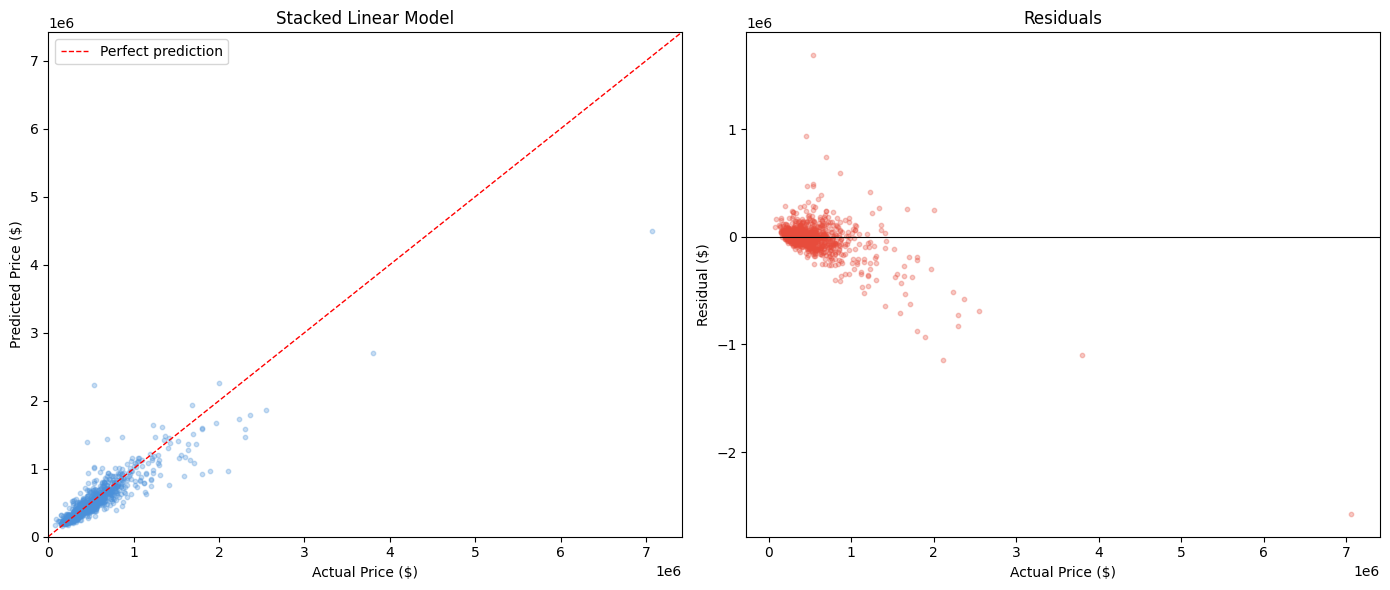

In [13]:
y_pred_stacked = np.expm1(stacked_pred_log)
y_pred_stacked = np.clip(y_pred_stacked, 0, None)

stacked_metrics = print_metrics(y_test.values, y_pred_stacked, "Stacked Linear Model")
segment_mape(y_test.values, y_pred_stacked, save_name = "stacked_segment_mape.csv")

plot_predictions(
    y_test.values, y_pred_stacked,
    title = "Stacked Linear Model",
    save_name = "stacked_model_predictions.png",
)

## 7. XGBoost Benchmark

In [14]:
print("[6/7] Training XGBoost benchmark ...")

y_train_log = np.log1p(y_train)

param_dist = {
    "n_estimators": [300, 500, 700, 1000, 1500],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha": [0, 0.01, 0.1, 0.5],
    "reg_lambda": [0.5, 1.0, 2.0, 5.0],
    "gamma": [0, 0.1, 0.3],
}

# Pre-compute fold-specific feature engineering to avoid data leak
print("  Pre-computing fold-specific features ...")
kf_xgb = KFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)
fold_data = []
for train_idx, val_idx in kf_xgb.split(X_train):
    fe_fold = FeatureEngineer()
    X_tr_fe_fold = fe_fold.fit_transform(X_train.iloc[train_idx], y_train.iloc[train_idx])
    X_val_fe_fold = fe_fold.transform(X_train.iloc[val_idx])
    fold_data.append((X_tr_fe_fold, X_val_fe_fold, train_idx, val_idx))

# Manual randomized search with leak-free CV
print("  Tuning XGBoost (RandomizedSearch with FE refit per fold) ...")
rng = np.random.RandomState(RANDOM_STATE)
best_score = -np.inf
best_xgb_params = None

for i in range(50):
    params = {k: rng.choice(v) for k, v in param_dist.items()}
    fold_scores = []

    for X_tr_fe_fold, X_val_fe_fold, train_idx, val_idx in fold_data:
        model = XGBRegressor(
            objective = "reg:squarederror",
            random_state = RANDOM_STATE,
            n_jobs = 2,
            verbosity = 0,
            **params,
        )
        model.fit(X_tr_fe_fold, np.log1p(y_train.iloc[train_idx]))
        pred = model.predict(X_val_fe_fold)
        score = -mean_absolute_error(np.log1p(y_train.iloc[val_idx]), pred)
        fold_scores.append(score)

    mean_score = np.mean(fold_scores)
    if mean_score > best_score:
        best_score = mean_score
        best_xgb_params = params

print(f"  Best XGBoost params: {best_xgb_params}")

# Refit on full training data
xgb_model = XGBRegressor(
    objective = "reg:squarederror",
    random_state = RANDOM_STATE,
    n_jobs = 2,
    verbosity = 0,
    **best_xgb_params,
)
xgb_model.fit(X_train_fe, y_train_log)

print("[6/7] Task completed")

[6/7] Training XGBoost benchmark ...
  Pre-computing fold-specific features ...
  Tuning XGBoost (RandomizedSearch with FE refit per fold) ...
  Best XGBoost params: {'n_estimators': np.int64(1500), 'max_depth': np.int64(4), 'learning_rate': np.float64(0.01), 'subsample': np.float64(0.7), 'colsample_bytree': np.float64(0.6), 'min_child_weight': np.int64(1), 'reg_alpha': np.float64(0.1), 'reg_lambda': np.float64(0.5), 'gamma': np.float64(0.0)}
[6/7] Task completed



  XGBoost Benchmark
  MAPE     : 0.1564  (15.64%)
  MAE      : $89,018
  RMSE     : $207,897
  R2       : 0.7390
  R2 (log) : 0.8350

  Plot saved to results/xgboost_predictions.png


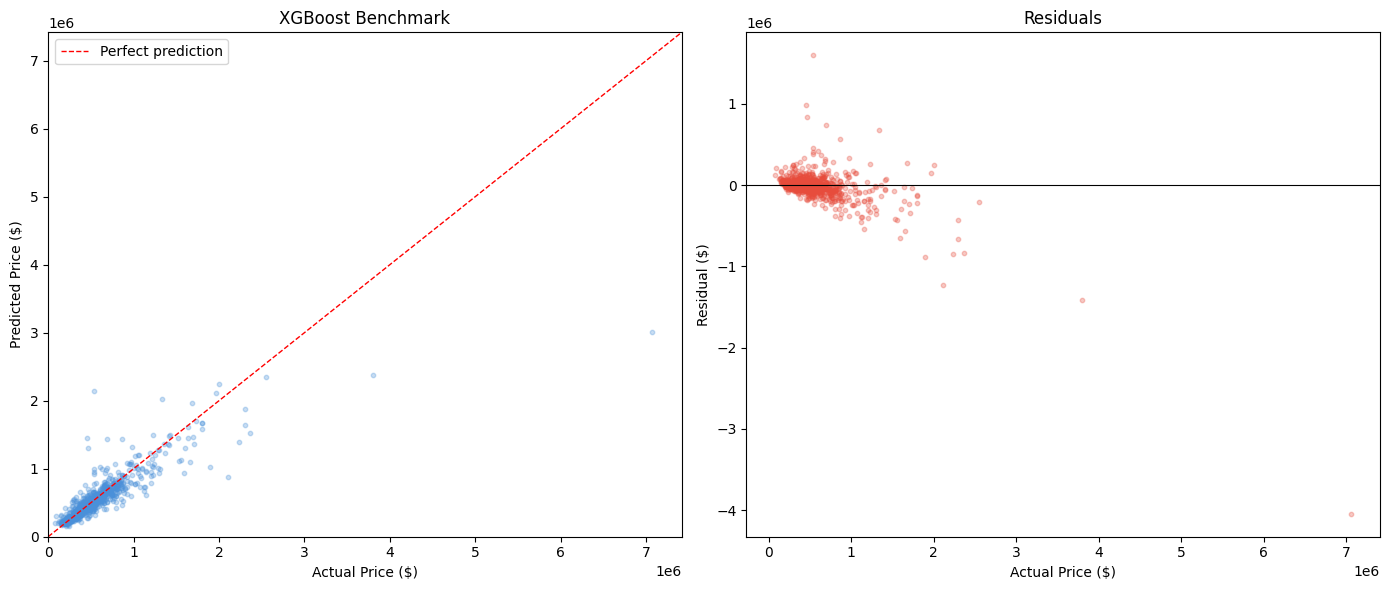

[6/7] Task completed


In [15]:
y_pred_xgb = np.expm1(xgb_model.predict(X_test_fe))
y_pred_xgb = np.clip(y_pred_xgb, 0, None)

xgb_metrics = print_metrics(y_test.values, y_pred_xgb, "XGBoost Benchmark")

plot_predictions(
    y_test.values, y_pred_xgb,
    title = "XGBoost Benchmark",
    save_name = "xgboost_predictions.png",
)

print("[6/7] Task completed")

## 8. Final Comparison & Save Results

In [16]:
print("[7/7] Final comparison ...")

if stacked_metrics["mape"] < linear_metrics["mape"]:
    final_linear_metrics = stacked_metrics
    final_linear_name = "Stacked Linear"
else:
    final_linear_metrics = linear_metrics
    final_linear_name = best_name

print("\n" + "=" * 65)
print("  MODEL COMPARISON")
print("=" * 65)
print(f"  {'Metric':<12} {'Single Best':>14} {'Stacked':>14} {'XGBoost':>14}")
print(f"  {'-'*12} {'-'*14} {'-'*14} {'-'*14}")
for metric in ["mape", "mae", "rmse", "r2", "r2_log"]:
    lv = linear_metrics[metric]
    sv = stacked_metrics[metric]
    xv = xgb_metrics[metric]
    if metric in ("mape", "r2", "r2_log"):
        print(f"  {metric.upper():<12} {lv:>13.4f} {sv:>13.4f} {xv:>13.4f}")
    else:
        print(f"  {metric.upper():<12} ${lv:>12,.0f} ${sv:>12,.0f} ${xv:>12,.0f}")
print("=" * 65)

print("[7/7] Task completed")

[7/7] Final comparison ...

  MODEL COMPARISON
  Metric          Single Best        Stacked        XGBoost
  ------------ -------------- -------------- --------------
  MAPE                0.1681        0.1674        0.1564
  MAE          $      94,901 $      93,972 $      89,018
  RMSE         $     180,765 $     183,677 $     207,897
  R2                  0.8026        0.7962        0.7390
  R2_LOG              0.8222        0.8238        0.8350
[7/7] Task completed


In [17]:
# Save results summary
with open(os.path.join(RESULTS_DIR, "summary.txt"), "w") as f:
    f.write(f"Single Best Linear Model: {best_name}\n")
    f.write(f"  MAPE:     {linear_metrics['mape']:.4f}\n")
    f.write(f"  MAE:      ${linear_metrics['mae']:,.0f}\n")
    f.write(f"  RMSE:     ${linear_metrics['rmse']:,.0f}\n")
    f.write(f"  R2:       {linear_metrics['r2']:.4f}\n")
    f.write(f"  R2 (log): {linear_metrics['r2_log']:.4f}\n")

    f.write(f"\nStacked Linear Model:\n")
    f.write(f"  MAPE:     {stacked_metrics['mape']:.4f}\n")
    f.write(f"  MAE:      ${stacked_metrics['mae']:,.0f}\n")
    f.write(f"  RMSE:     ${stacked_metrics['rmse']:,.0f}\n")
    f.write(f"  R2:       {stacked_metrics['r2']:.4f}\n")
    f.write(f"  R2 (log): {stacked_metrics['r2_log']:.4f}\n")

    f.write(f"\nBest Linear Approach: {final_linear_name}\n")
    f.write(f"  MAPE: {final_linear_metrics['mape']:.4f}\n")

    f.write(f"\nXGBoost Benchmark:\n")
    f.write(f"  MAPE:     {xgb_metrics['mape']:.4f}\n")
    f.write(f"  MAE:      ${xgb_metrics['mae']:,.0f}\n")
    f.write(f"  RMSE:     ${xgb_metrics['rmse']:,.0f}\n")
    f.write(f"  R2:       {xgb_metrics['r2']:.4f}\n")
    f.write(f"  R2 (log): {xgb_metrics['r2_log']:.4f}\n")

print(f"Results saved to {os.path.join(RESULTS_DIR, 'summary.txt')}")

# Save coefficients
coefs.to_csv(os.path.join(RESULTS_DIR, "linear_coefficients.csv"), index = False)
print(f"Coefficients saved to {os.path.join(RESULTS_DIR, 'linear_coefficients.csv')}")

# Save CV results
cv_df = pd.DataFrame([
    {"model": name, "cv_mape": m, "cv_std": s}
    for name, (m, s) in cv_results.items()
]).sort_values("cv_mape")

cv_df.to_csv(os.path.join(RESULTS_DIR, "cv_results.csv"), index = False)
print(f"CV results saved to {os.path.join(RESULTS_DIR, 'cv_results.csv')}")

print("Pipeline complete!")

Results saved to results/summary.txt
Coefficients saved to results/linear_coefficients.csv
CV results saved to results/cv_results.csv
Pipeline complete!
